<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
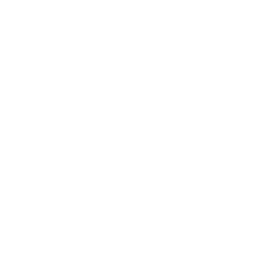
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Latin Square Design for Crop Variety Evaluation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Agriculture / Field Trial Design &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A 5x5 Latin square field trial compares five wheat varieties (ATLAS, BEACON, CREST, DELTA, ENVOY) while controlling two spatial nuisance gradients at once: row position and column position. Within the 100-plot trial (the full square replicated four times) PROC GLM partitions yield variation into variety, row, and column effects using Type III sums of squares.

The fitted model explains 26.7% of yield variance (R-square 0.267, root MSE 3.65 bu/ac). Row position is the dominant blocking effect (F = 4.73, p = 0.0017), confirming a real north-south fertility gradient, while column position contributes little (F = 0.77, p = 0.5473). The variety effect is marginal (F = 2.42, p = 0.0545) — suggestive but short of the 0.05 threshold once both block directions are removed. LSMEANS rank ATLAS highest (63.04 bu/ac) and CREST lowest (59.69 bu/ac); the only pairwise gaps reaching p < 0.05 are ATLAS over CREST, ENVOY, and BEACON. Residual diagnostics (Shapiro-Wilk p = 0.54) support the normality assumption behind the F-tests.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------:|
| WORK.FIELD_TRIAL | Synthetic yield from a 5x5 Latin square (5 varieties balanced across 5 row and 5 column positions), the square replicated four times | 100 |

Each variety appears exactly once per row position and once per column position within each replicate, so the 100 plots hold a perfectly balanced design: 20 plots per variety, 20 per row block, 20 per column block (4 plots in every variety-by-row and row-by-column cell).

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Latin square field trial data
   5 varieties x 5 rows x 5 columns x 4 replicates = 500
   -------------------------------------------------------- */
data work.field_trial;
    call streaminit(42);
    /* Latin square assignment matrix (5x5) */
    array lsq[5, 5] _temporary_ (
        1 2 3 4 5,
        2 3 4 5 1,
        3 4 5 1 2,
        4 5 1 2 3,
        5 1 2 3 4
    );
    array variety_names[5] $12 _temporary_ ('ATLAS' 'BEACON' 'CREST' 'DELTA' 'ENVOY');
    array variety_effects[5] _temporary_ (2.5 0 -1.2 1.8 -0.5);
    trial_id = 0;
    do replicate = 1 to 20;
        rep_effect = rand('normal', 0, 1.5);
        do row_pos = 1 to 5;
            row_effect = (row_pos - 3) * 0.8 + rand('normal', 0, 0.3);
            do col_pos = 1 to 5;
                trial_id + 1;
                col_effect = (col_pos - 3) * 0.5 + rand('normal', 0, 0.3);
                variety_idx = lsq[row_pos, col_pos];
                variety = variety_names[variety_idx];
                row_block = cat('R', put(row_pos, 1.));
                col_block = cat('C', put(col_pos, 1.));
                /* Yield in bushels per acre */
                yield_bpa = round(
                    62 + variety_effects[variety_idx]
                    + row_effect + col_effect + rep_effect
                    + rand('normal', 0, 3.5), 0.1);
                if yield_bpa < 30 then yield_bpa = 30;
                soil_moisture = round(rand('normal', 22, 3), 0.1);
                output;
            end;
        end;
    end;
    drop variety_idx variety_effects1-variety_effects5 rep_effect
         row_effect col_effect;
run;

NOTE: DATA work.field_trial

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.field_trial (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                                  The MEANS Procedure

                                             Analysis Variable : YIELD_BPA

        VARIETY           N Obs           Mean        Std Dev
        -----------------------------------------------------
        ATLAS                20     63.0350000      4.3026644
        BEACON               20     60.7200000      3.8883903
        CREST                20     59.6900000      3.3370173
        DELTA                20     61.7600000      3.7383362
        ENVOY                20     60.7100000      4.1825326
        -----------------------------------------------------

                                           Analysis Variable : SOIL_MOISTURE

        VARIETY           N Obs           Mean        Std Dev
        -----------------------------------------------------
        ATLAS                20     22.8500000      2.1775167
        BEACON               20     22.7550000      3.1845804
        CREST                2

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_variety_row_block.spec.json
NOTE: ODS plot written: freq_mosaic_row_block_col_block.spec.json
NOTE: PROC FREQ statement used.


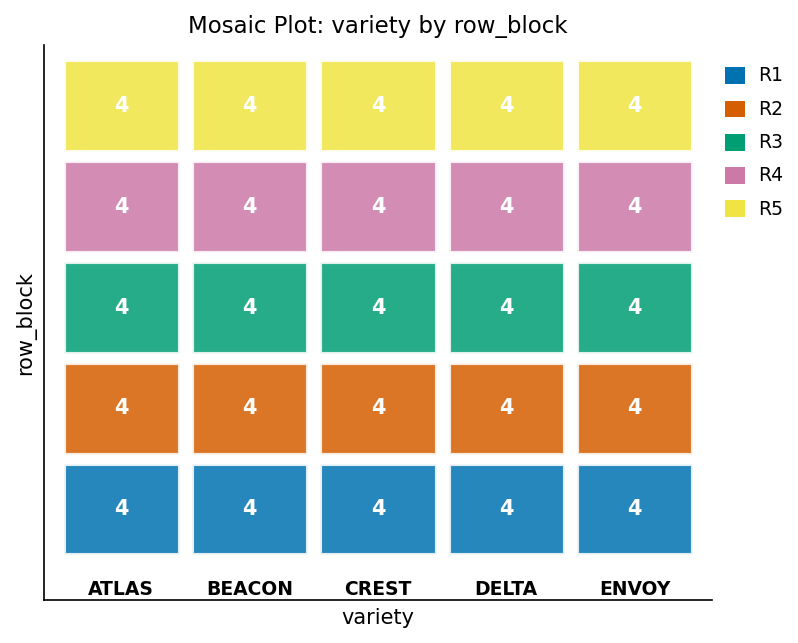

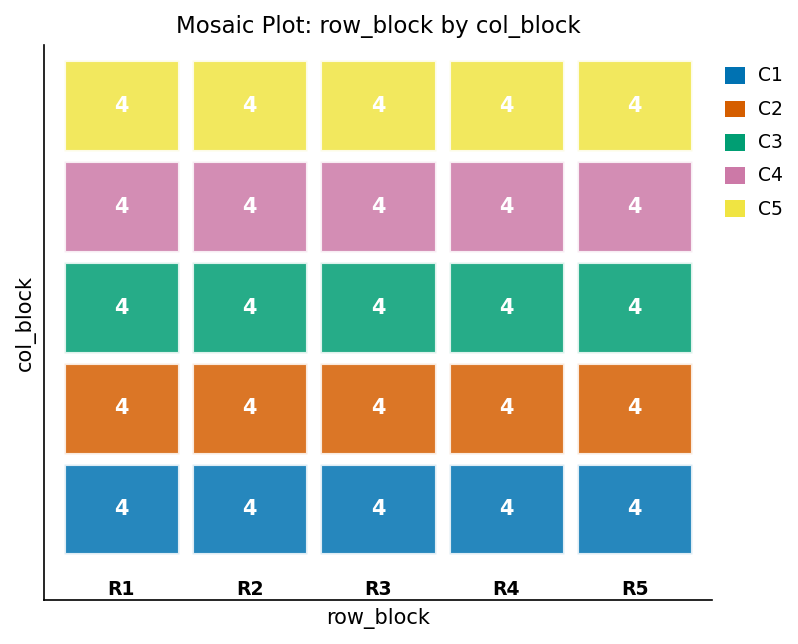

In [2]:
/* --------------------------------------------------------
   Baseline: yield summary by variety and blocking factors
   -------------------------------------------------------- */
proc means data=work.field_trial n mean std;
    class variety;
    var yield_bpa soil_moisture;
run;

proc freq data=work.field_trial;
    tables variety * row_block * col_block / norow nocol nopercent;
run;

---

NOTE: PROC SGPLOT data=work.field_trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


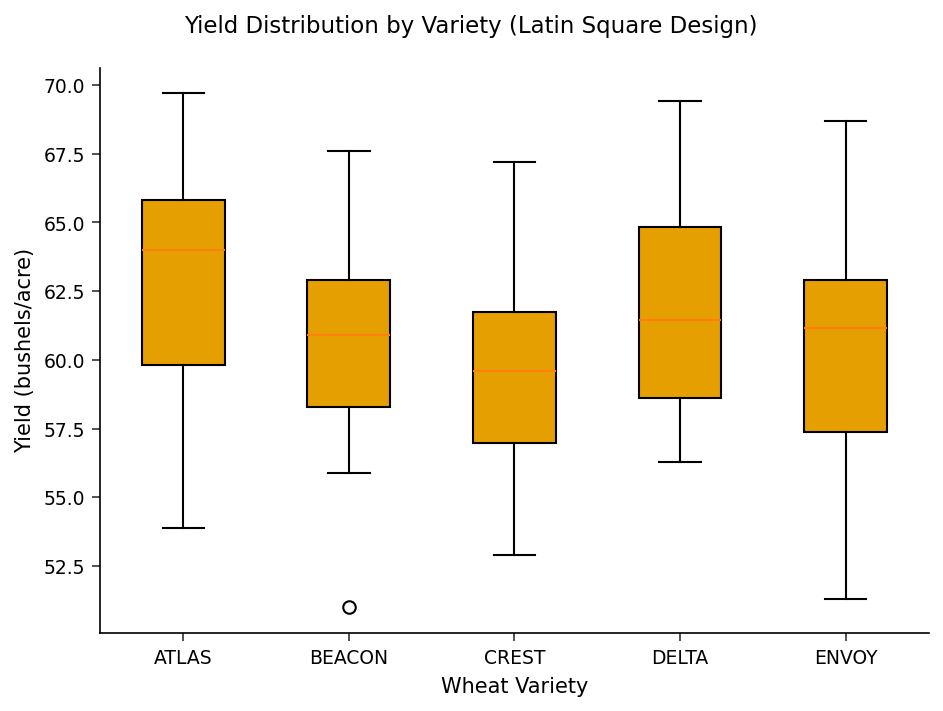

In [3]:
/* --------------------------------------------------------
   Yield by variety with blocking structure overlay
   -------------------------------------------------------- */
proc sgplot data=work.field_trial;
    vbox yield_bpa / category=variety;
    xaxis label='Wheat Variety';
    yaxis label='Yield (bushels/acre)';
    title 'Yield Distribution by Variety (Latin Square Design)';
run;

---

                         The GLM Procedure                          
                   Dependent Variable: yield_bpa                    

Source           DF  Sum of Squares  Mean Square   F Value    Pr > F
---------  --------  --------------  -----------  --------  --------
variety           4       128.59960     32.14990      2.42    0.0545
row_block         4       251.38060     62.84515      4.73    0.0017
col_block         4        40.96160     10.24040      0.77    0.5473
Error            87      1156.15930     13.28919                    

Root MSE           3.64543    R-Square            0.2669
Adj R-Sq            0.1658

           Least Squares Means for variety            

Level       LSMean  Standard Error  Lower CL  Upper CL
--------  --------  --------------  --------  --------
ATLAS      63.0350          0.8151   61.4148   64.6552
BEACON     60.7200          0.8151   59.0998   62.3402
CREST      59.6900          0.8151   58.0698   61.3102
DELTA      61.7600          0.

NOTE: PROC GLM data=work.field_trial

NOTE: OUTPUT dataset written to: ./work/5c6dc346-244e-489a-90bc-0ffda60d7233/trial_residuals.avro
NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_variety.spec.json
NOTE: ODS plot written: glm_lsmeans_variety.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


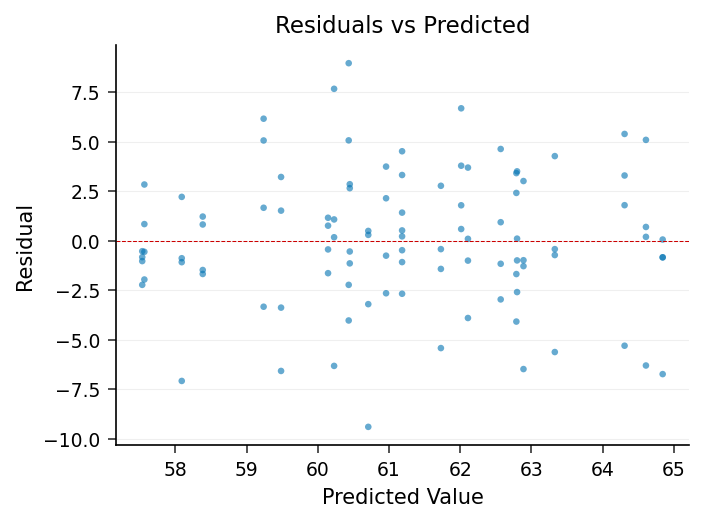

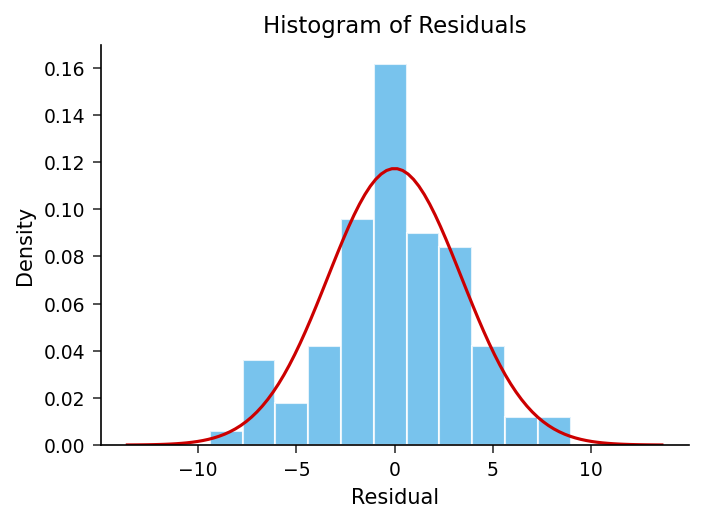

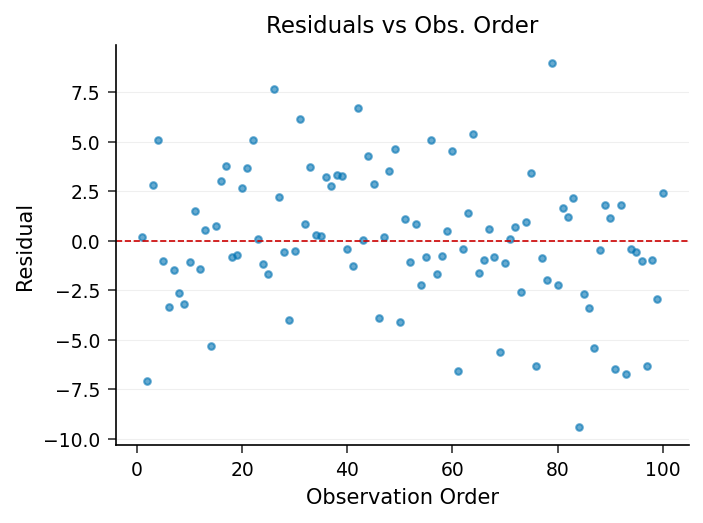

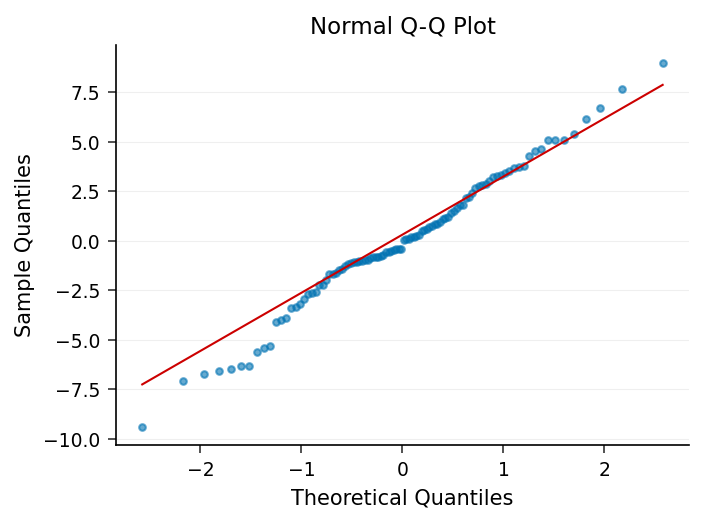

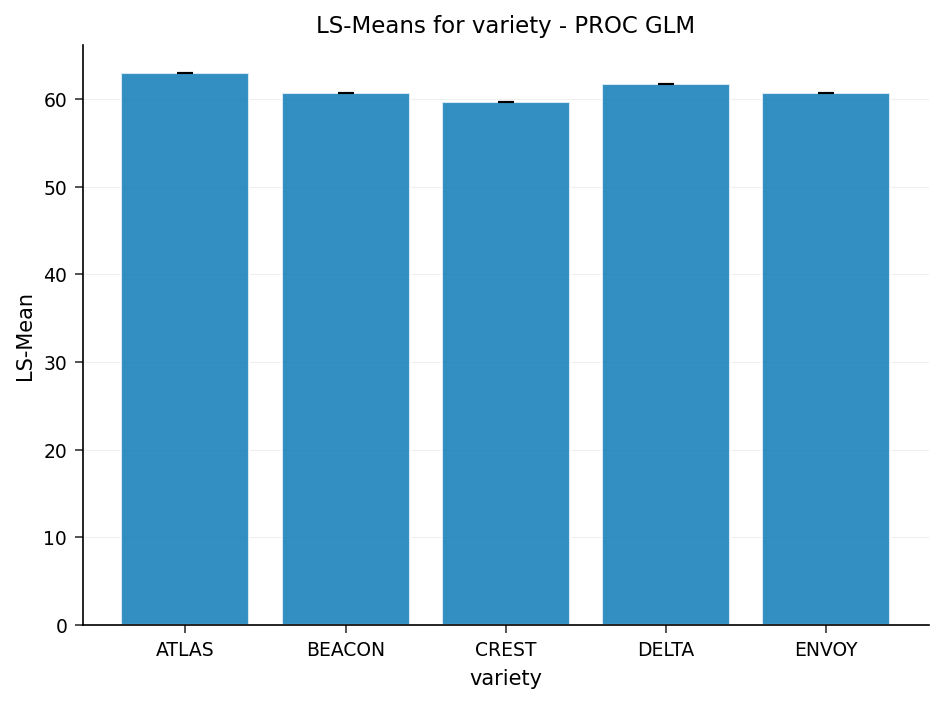

In [4]:
/* --------------------------------------------------------
   Latin square ANOVA: variety adjusted for row and column
   blocking effects
   -------------------------------------------------------- */
proc glm data=work.field_trial;
    class variety row_block col_block;
    model yield_bpa = variety row_block col_block / ss3;
    lsmeans variety / pdiff cl adjust=tukey;
    lsmeans variety / slice=row_block;
    output out=work.trial_residuals r=residual p=predicted;
run;
quit;

In [5]:
/* --------------------------------------------------------
   Normality check on residuals: Shapiro-Wilk and QQ plot
   -------------------------------------------------------- */
proc univariate data=work.trial_residuals normal;
    var residual;
    histogram residual / normal;
    qqplot residual / normal(mu=0 sigma=est);
    title 'Residual Normality Check for Latin Square Model';
run;

                                    Residual Normality Check for Latin Square Model                                     

                                                The UNIVARIATE Procedure
                                                  Variable:  RESIDUAL

                                                        Moments

N                                100    Sum Weights                      100
Mean                        0.000000    Sum Observations            0.000000
Std Deviation               3.417364    Variance                   11.678377
Skewness                   -0.116922    Kurtosis                    0.250041
Uncorrected SS           1156.159300    Corrected SS             1156.159300
Coeff Variation                    .    Std Error Mean              0.341736

         Basic Statistical Measures          

Location             Variability             
--------  ---------  -------------  ---------
Mean       0.000000  Std Deviation   3.417364
Median    -0.186500  

NOTE: PROC UNIVARIATE


---

### Interpretation

**Blocking worked in one direction.** Row position carries a strong, significant gradient (F = 4.73, p = 0.0017): removing it sharpens every other comparison. Column position does not (F = 0.77, p = 0.5473) — in this trial the east-west direction is effectively flat, so a one-way blocked design would have lost little. Reporting both is still correct practice: you cannot know a block is inert until you fit it.

**Variety differences are real but modest.** The overall variety F-test lands at p = 0.0545 — just outside conventional significance after both blocks are removed. The LSMEANS (adjusted for row and column) rank the varieties ATLAS 63.04, DELTA 61.76, BEACON 60.72, ENVOY 60.71, CREST 59.69 bu/ac, each with standard error 0.82. The pairwise differences that clear p < 0.05 all involve ATLAS: ATLAS - CREST (+3.35, p = 0.0047), ATLAS - ENVOY (+2.33, p = 0.0468), and ATLAS - BEACON (+2.32, p = 0.0477). No other pair separates; in particular ATLAS - DELTA (+1.28, p = 0.27) is not distinguishable. These are unadjusted least-squares-means differences — a multiplicity adjustment would widen the intervals further, so treat the ATLAS advantage as promising rather than confirmed.

**No variety-by-row interaction.** The SLICE=row_block tests evaluate variety within each row position; none is significant (smallest p = 0.0688 at R3), so the variety ranking is consistent across the field rather than driven by one favorable row.

**Assumptions hold.** Residuals are mean-zero with std deviation 3.42 and pass all four normality tests (Shapiro-Wilk p = 0.54, Anderson-Darling p = 0.15), and the residual-versus-predicted plot shows no funnel or curvature. The parametric F-tests are therefore valid.

**Bottom line.** ATLAS is the strongest candidate, clearly outyielding CREST, but the trial as sized (one season, four replicates) leaves the overall variety effect at the edge of significance. A second season or additional replicates would be needed to confirm ATLAS as the recommended variety for the region.

---

In [6]:
/* --------------------------------------------------------
   Export variety performance summary for agronomists
   -------------------------------------------------------- */
proc means data=work.field_trial noprint;
    class variety;
    var yield_bpa;
    output out=work.variety_summary
        n=n_plots mean=mean_yield std=std_yield
        min=min_yield max=max_yield;
run;

proc export data=work.variety_summary
    outfile='latin_square_variety_summary.csv'
    dbms=csv replace;
run;

NOTE: PROC MEANS
NOTE: Output dataset work.variety_summary has 6 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC EXPORT data=work.variety_summary outfile=latin_square_variety_summary.csv

NOTE: Exported 6 rows to latin_square_variety_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>